In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
from glob import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import string
import sklearn.model_selection
import itertools
import random

In [2]:
!pip install tensorflow==2.15
!pip install keras-ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: keras
    Found existing installation: keras 3.3.3
    Uninstalling keras-3.3.3:
      Successfully uninstalled keras-3.3.3
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.16.2
    Uninstalling tensorboard-2.16.2:
      

In [3]:
import keras_ocr

temp_dir = '/kaggle/temp/'
subfolder_expresion = "**"

backgrounds = glob(os.path.join(temp_dir,subfolder_expresion,"*.jpg"),recursive=True)
if len(backgrounds)==0:
    backgrounds = keras_ocr.data_generation.get_backgrounds(cache_dir=temp_dir)
    backgrounds = glob(os.path.join(temp_dir,subfolder_expresion,"*.jpg"),recursive=True)
len(backgrounds)

2024-11-19 18:40:23.306191: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-19 18:40:23.306271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-19 18:40:23.308328: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Looking for /kaggle/temp/backgrounds.zip


1034

In [4]:
alphabet = string.ascii_letters + string.digits  + '. '
fonts = glob(os.path.join(temp_dir,subfolder_expresion,"*.ttf"),recursive=True)
substr = [
            'rubik',
            'kumarone',
         ]
def Filter(string, substr):
    return [str for str in string if
             not any(sub in str for sub in substr)]
     

if len(fonts)==0:
    fonts = keras_ocr.data_generation.get_fonts(
        alphabet=alphabet,
        cache_dir=temp_dir
    )
    fonts = glob(os.path.join(temp_dir,subfolder_expresion,"*.ttf"),recursive=True)
    


fonts_clean = Filter(fonts, substr)
fonts = fonts_clean
len(fonts)

Looking for /kaggle/temp/fonts.zip
Unzipping fonts ZIP file.


Filtering fonts.: 100%|██████████| 2746/2746 [00:11<00:00, 248.31it/s]


2733

In [5]:
def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)

In [6]:
def text_generator():
    alpha_modif = alphabet+' '
    chars = "".join( [random.choice(alpha_modif) for i in range(len(alpha_modif))] )
    return chars
print('The first generated text is:', text_generator())

The first generated text is: JV9nJbGZztzbEdl0akvoxvXW2cPQh0ju9rFkoMgPm9BqQ1ubY0xNUyh3DFr39 teo


In [7]:
def dummy(image, fontsize=150, margin=10):
    return np.array([[[margin,margin],[margin,image.shape[0]-margin],[image.shape[1]-margin,image.shape[0]-margin],[image.shape[1]-margin,margin]]]),True

keras_ocr.data_generation.get_maximum_uniform_contour = dummy


Combinaciones de fondos y tipografias en el dataset de validacion:   28119
Mostrando ejemplos para los primeros 100 crops generados:  yI
nCCS2l
vnCW
WQVGk
/kaggle/temp/fonts/roboto/Roboto-Light.ttf /kaggle/temp/backgrounds/1024px-unidentified_young_soldier_in_confederate_infantry_uniform.jpg


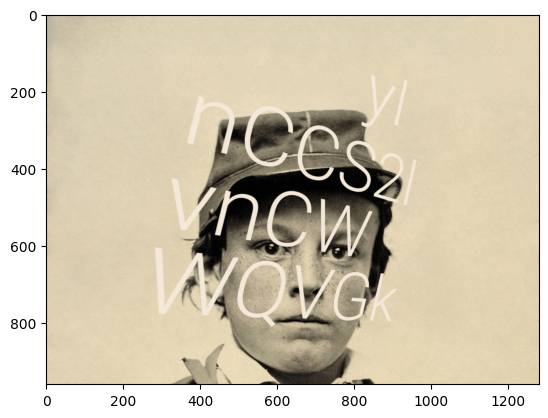

Mostrando ejemplos para los primeros 100 crops generados:  f
lKYt7R
hF2mrp
7zBEn
/kaggle/temp/fonts/gudea/Gudea-Bold.ttf /kaggle/temp/backgrounds/1024px-muzeum_su%c5%82kowskich_-_zabytkowy_witra%c5%bc.jpg


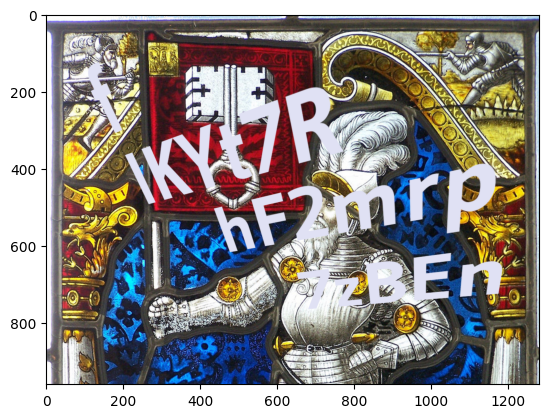

Mostrando ejemplos para los primeros 100 crops generados:  H
ZuUESZKSJi
S1qUtVmus
xVkPGjIDY
/kaggle/temp/fonts/gudea/Gudea-Bold.ttf /kaggle/temp/backgrounds/1024px-cute_monkey_cropped.jpg


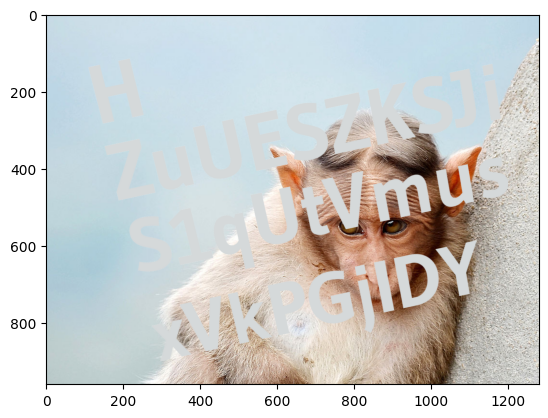

Mostrando ejemplos para los primeros 100 crops generados:  lb
bm
y1wifp
cNC
/kaggle/temp/fonts/dmsans/DMSans-Italic.ttf /kaggle/temp/backgrounds/1024px-bibliotheque-musee-guimet.jpg


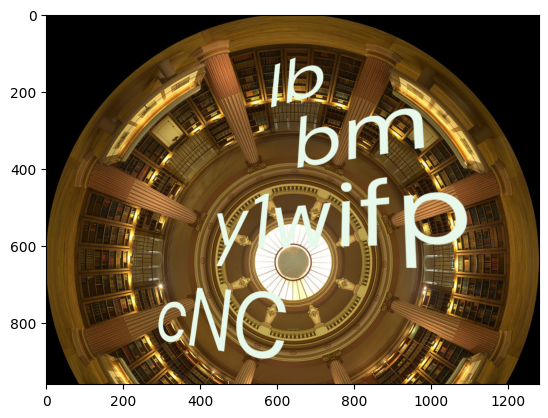

Mostrando ejemplos para los primeros 100 crops generados:  3pVGk
DGReeX
.K7idY b
/kaggle/temp/fonts/sairacondensed/SairaCondensed-Regular.ttf /kaggle/temp/backgrounds/1024px-m%c3%bc%c3%bcrlooga_%28arabidopsis_thaliana%29_lehekarv_%28trihhoom%29_311_0804.jpg


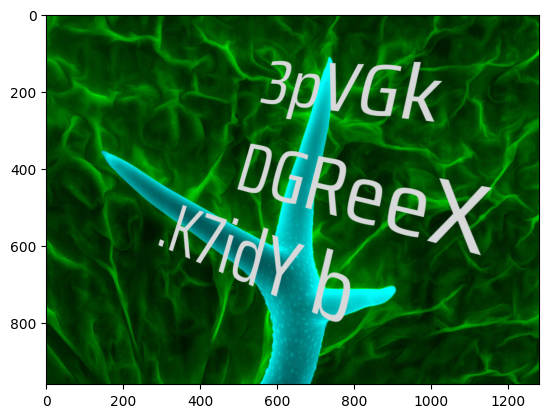

Mostrando ejemplos para los primeros 100 crops generados:  hq
zdS4G
U1hKgbr o
1HtKwdH0
ev
/kaggle/temp/fonts/nanummyeongjo/NanumMyeongjo-Bold.ttf /kaggle/temp/backgrounds/1024px-dryas_iulia%2c_mariposario_de_icod_de_los_vinos%2c_tenerife%2c_espa%c3%b1a%2c_2012-12-13%2c_dd_01.jpg


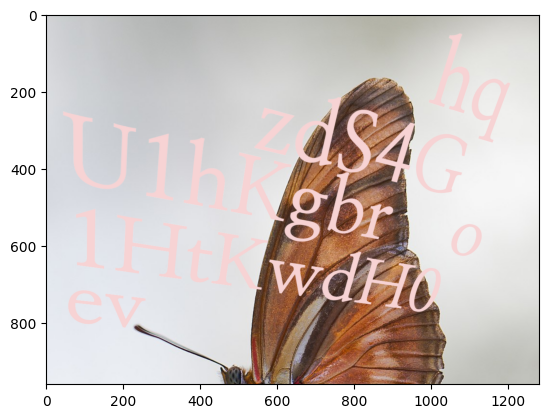

Numero de crops de letras validas generadas para el split 1: 10059


In [17]:
split_index = 1 # validation
max_val_samples = 10000 ##
file_i = 0
mostrar_n = 100
combinaciones = [(ff,bb) for ff,bb in itertools.product(font_splits[split_index],background_splits[split_index])]
random.shuffle(combinaciones)
print('Combinaciones de fondos y tipografias en el dataset de validacion:  ',len(combinaciones))
for current_fonts, current_backgrounds in combinaciones:
    image_generator = keras_ocr.data_generation.get_image_generator(
                height=960,
                width=1280,
                text_generator=[text_generator()],
                font_groups={
                    alphabet: [current_fonts]
                },
                backgrounds=[current_backgrounds],
                font_size= 200,
                margin=50,
                rotationX=(-0.05, 0.05),
                rotationY=(-0.05, 0.05),
                rotationZ=(-15, 15),
                draw_contour_text = False,
            )
    try:
        image, lines = next(image_generator)
        if file_i <= mostrar_n:
            text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
            print(f'Mostrando ejemplos para los primeros {mostrar_n} crops generados: ', text)
            print(current_fonts, current_backgrounds)
            plt.imshow(image)
            plt.show()
        for linea in lines:
            for letra in linea:
                ##Aca cropear cada letra, salvar y validar
                file_i+=1

    except Exception as e:
        print(e)
        print(current_fonts, current_backgrounds)
        print(image.dtype, crop.dtype, image.shape, image.max())

    if file_i >= max_val_samples:
        print(f"Numero de crops de letras validas generadas para el split {split_index}: {file_i}")
        break ###
